# XÂY DỰNG MÔ HÌNH PHÂN CỤM ĐA CẤP TRÊN TẬP DỮ LIỆU MUA SẮM TẠI SIÊU THỊ

## 1. Mục tiêu

- Làm quen với các kỹ thuật phân cụm dữ liệu trong học máy không giám sát.
- Xây dựng các đặc trưng hành vi khách hàng dựa trên mô hình RFM (Recency – Frequency – Monetary) từ tập dữ liệu OnlineRetail.csv.
- Áp dụng phương pháp phân cụm đa cấp hợp nhất (Agglomerative Clustering) lên dữ liệu khách hàng sau khi chuẩn hóa.
- Thực hiện phân cụm khách hàng bằng mô hình K-Means để đối chiếu với phân cụm đa cấp.
- Sử dụng biểu đồ trực quan để quan sát và so sánh cấu trúc phân cụm giữa hai mô hình.
- Đánh giá chất lượng phân cụm bằng chỉ số Silhouette Score nhằm xác định mô hình phân cụm phù hợp hơn.
- Hiểu được ý nghĩa của phân cụm trong phân tích hành vi khách hàng và hỗ trợ chiến lược marketing.

## 2. Import & tải dữ liệu Online Retail vào notebook

In [52]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
retail = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

print("5 dòng đầu tiên của dữ liệu:")
print(retail.head())

print("Thông tin dữ liệu:")
print(retail.info())

5 dòng đầu tiên của dữ liệu:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  


**Nhận xét dữ liệu ban đầu:**
- Số dòng dữ liệu: 541,909 dòng
- Dữ liệu gồm nhiều thông tin giao dịch bán hàng: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country…
- Một số cột chứa giá trị thiếu, đặc biệt là CustomerID – không phải giao dịch nào cũng có mã khách hàng.
- Dữ liệu có các giao dịch số lượng âm (trả hàng) hoặc giá trị âm → cần xử lý.
- Đây là dữ liệu thô, chưa sẵn sàng để phân cụm → cần làm sạch và tạo đặc trưng RFM trước khi đưa vào mô hình.

## 3. Tiền xử lý dữ liệu

### 3.1 Làm sạch dữ liệu

In [53]:
# Loại bỏ các dòng không có CustomerID
df = retail.dropna(subset=["CustomerID"])

# Loại bỏ các giao dịch có Quantity ≤ 0
df = df[df["Quantity"] > 0]

# Loại bỏ các giao dịch có UnitPrice ≤ 0
df = df[df["UnitPrice"] > 0]

# Chuyển ngày giao dịch sang dạng datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

# Tạo cột TotalPrice = Quantity × UnitPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Ngày tham chiếu
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Tính RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
})

# Chuẩn hoá dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(rfm)

**Nhận xét:**
- Các giao dịch không có mã khách hàng không thể sử dụng cho bài toán phân cụm theo RFM. Do đó, cần loại bỏ các dòng CustomerID.
- Một số giao dịch có số lượng âm (trả hàng) hoặc bằng 0. Những giá trị Quanlity không phản ánh hành vi mua hàng → cần loại bỏ.
- Các dòng UnitPrice có giá sản phẩm bằng 0 hoặc âm là lỗi nhập liệu hoặc điều chỉnh hệ thống → không phù hợp cho phân tích chi tiêu.
- Chuyển ngày giao dịch sang dạng datetime là cần thiết để tính Recency (số ngày kể từ giao dịch gần nhất).
- TotalPrice là thành phần quan trọng trong chỉ số Monetary, biểu diễn tổng chi tiêu của khách hàng.

### 3.2 Xem dữ liệu sau khi làm sạch

In [54]:
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column 

**Nhận xét dữ liệu sau khi đã làm sạch:**
- Sau khi loại bỏ các dòng thiếu CustomerID, các giao dịch có Quantity ≤ 0 và UnitPrice ≤ 0, dataset còn 397,884 dòng hợp lệ.
- Dữ liệu bao gồm 9 cột và tất cả đều không còn giá trị thiếu (non-null).
- Các kiểu dữ liệu đã được chuẩn hóa hợp lý:
  + InvoiceDate → datetime64
  + Quantity → int64
  + UnitPrice, TotalPrice → float64
  + Các cột mã và mô tả giữ dạng object (chuỗi).
- Việc thêm cột TotalPrice = Quantity × UnitPrice giúp chuẩn bị trực tiếp cho việc tính đặc trưng Monetary trong mô hình RFM.
- Dữ liệu sau làm sạch đã đồng nhất, hợp lệ và sẵn sàng cho bước tiền xử lý RFM và phân cụm.

## 4. Xây dựng mô hình phân cụm đa cấp theo cách tiếp cận của thư viện scikit-learn và hiển thị kết quả phân cụm trên dữ liệu

### 4.1 Triển khai mô hình Agglomerative Clustering

In [55]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Mô hình phân cụm đa cấp với 3 cụm, sử dụng linkage = 'average'
ac = AgglomerativeClustering(
    n_clusters=3,
    linkage="average"
)

# Tiến hành phân cụm
ac_clusters = ac.fit_predict(X)

# Thêm nhãn cụm vào bảng RFM để tiện quan sát
rfm["Cluster_AC"] = ac_clusters

### 4.2 Hiển thị kết quả phân cụm trên dữ liệu

Để trực quan hóa, ta sử dụng 2 thuộc tính có ý nghĩa nhất trong RFM:
Frequency (tần suất mua hàng) và Monetary (tổng chi tiêu).

              Recency   Frequency       Monetary
Cluster_AC                                      
0            7.000000   41.142857  176606.164286
1            1.000000  205.000000   88772.395000
2           92.717025    4.119658    1731.951944


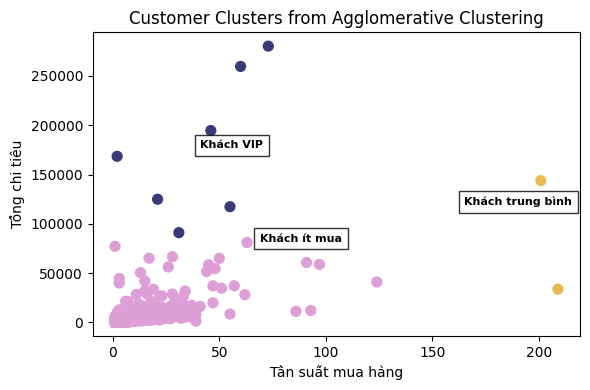

In [74]:
plt.figure(figsize=(6,4))
plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=ac_clusters,
    s=50,
    cmap="tab20b"
)

plt.title("Customer Clusters from Agglomerative Clustering")
plt.xlabel("Tần suất mua hàng")
plt.ylabel("Tổng chi tiêu")

# Tìm trung tâm từng cụm để đặt tên
unique_clusters = np.unique(ac_clusters)

# Thống kê để đặt tên đúng
print(rfm.groupby("Cluster_AC")[["Recency", "Frequency", "Monetary"]].mean())

# Màu và tên cụm
label_names = {
    0: "Khách VIP",
    1: "Khách trung bình",
    2: "Khách ít mua"
}

# Tinh chỉnh vị trí nhãn (dx, dy)
offsets = {
    0: (0, 0),
    1: (-40, 30000),
    2: (65, 80000),
}

for cluster in unique_clusters:
    cluster_points = rfm[ac_clusters == cluster]
    center_x = cluster_points["Frequency"].mean()
    center_y = cluster_points["Monetary"].mean()

    dx, dy = offsets[cluster]

    plt.text(center_x + dx, center_y + dy,
             label_names[cluster],
             fontsize=8, weight="bold",
             color="black",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

plt.tight_layout()
plt.show()

In [72]:
print(rfm.groupby("Cluster_AC")[["Recency","Frequency","Monetary"]].mean())


              Recency   Frequency       Monetary
Cluster_AC                                      
0            7.000000   41.142857  176606.164286
1            1.000000  205.000000   88772.395000
2           92.717025    4.119658    1731.951944


**Nhận xét biểu đồ phân cụm (Agglomerative Clustering – OnlineRetail RFM):**
- Mô hình phân cụm đa cấp đã chia khách hàng thành 3 nhóm rõ ràng dựa trên bộ đặc trưng RFM.
- Cụm “Khách VIP” gồm một số ít khách hàng có chi tiêu cực kỳ cao và tần suất mua ở mức trung bình.
- Cụm “Khách trung bình” bao gồm các khách hàng có tần suất mua rất cao nhưng chi tiêu ở mức khá; đây là nhóm khách hàng tiềm năng.
- Cụm “Khách ít mua” chiếm số lượng lớn, đặc trưng bởi tần suất mua thấp và chi tiêu thấp.
- Các cụm được tách biệt khá rõ ràng, ít chồng lấn, cho thấy Agglomerative phù hợp với dữ liệu RFM vốn có nhiều điểm ngoại lai.
- Một số điểm ngoại lai (outlier) có thể thấy rõ, ví dụ khách hàng có tần suất > 200 hoặc chi tiêu > 250,000, điều này là đặc trưng thường gặp của dữ liệu OnlineRetail.


## 5. Phân cụm sử dụng K-Means và so sánh với kết quả phân cụm đa cấp

               Recency  Frequency      Monetary
KM_cluster                                     
0           247.106285   1.582255    631.424206
1            41.454180   4.672755   1855.942345
2             6.038462  66.423077  85904.351538


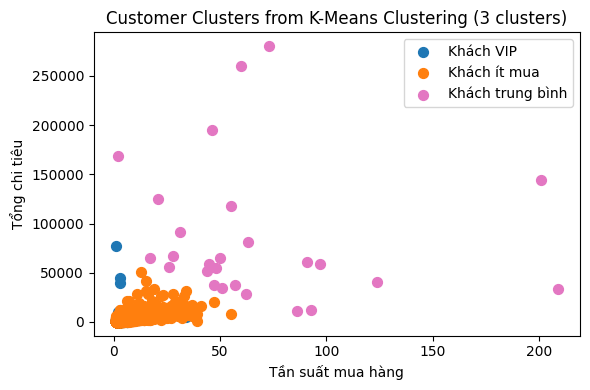

In [61]:
from sklearn.cluster import KMeans

# Mô hình K-Means với 3 cụm
km = KMeans(n_clusters=3, random_state=42, n_init=10)

# Tiến hành phân cụm
km_clusters = km.fit_predict(X)

# Thống kê để đặt tên đúng
rfm["KM_cluster"] = km_clusters
print(rfm.groupby("KM_cluster")[["Recency", "Frequency", "Monetary"]].mean())

# Màu và tên cụm
colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:pink"}
labels = {0: "Khách VIP", 1: "Khách ít mua", 2: "Khách trung bình"}

# Vẽ biểu đồ phân cụm
plt.figure(figsize=(6,4))

for c in colors:
    subset = rfm[km_clusters == c]
    plt.scatter(subset["Frequency"], subset["Monetary"],
                s=50, c=colors[c], label=labels[c])

plt.title("Customer Clusters from K-Means Clustering (3 clusters)")
plt.xlabel("Tần suất mua hàng")
plt.ylabel("Tổng chi tiêu")
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ phân cụm bằng K-Means (OnlineRetail – RFM):**
- Biểu đồ cho thấy dữ liệu được chia thành 3 cụm, tuy nhiên mức độ tách biệt không rõ ràng như mô hình phân cụm đa cấp (Agglomerative).
- Cụm màu cam tập trung phần lớn khách hàng, chủ yếu là những người có tần suất mua thấp (0–20) và chi tiêu nhỏ, đây là nhóm chiếm đa số trong tập dữ liệu.
- Cụm màu hồng bao gồm các khách hàng có tần suất mua trung bình (20–100) hoặc chi tiêu ở mức trung bình đến cao, nhưng ranh giới giữa cụm này và cụm khác khá mờ, cho thấy hiện tượng chồng lấn trong không gian dữ liệu.
- Cụm màu xanh đậm chỉ chứa một số ít khách hàng có giá trị chi tiêu rất cao, nhưng bị gom vào cùng một cụm nhỏ do K-Means tối ưu theo khoảng cách Euclidean, vốn nhạy cảm với outliers.
- Nhìn chung, K-Means không tách biệt cụm tốt bằng Agglomerative đối với dữ liệu RFM, đặc biệt khi tồn tại nhiều khách hàng ngoại lai có chi tiêu cao.

## 6. So sánh kết quả phân cụm của 2 mô hình với phương pháp tính Silhouette

In [62]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores for OnlineRetail RFM Dataset:\n")

print("K-Means Clustering:       ", silhouette_score(X, km_clusters))
print("Agglomerative Clustering: ", silhouette_score(X, ac_clusters))

Silhouette Scores for OnlineRetail RFM Dataset:

K-Means Clustering:        0.5941879366550106
Agglomerative Clustering:  0.9269452353774186


**Nhận xét so sánh:**
- Agglomerative Clustering đạt Silhouette Score ≈ 0.93, rất cao và vượt trội so với K-Means. Điều này cho thấy mô hình phân cụm đa cấp tạo ra các cụm rõ ràng, tách biệt tốt và phù hợp với cấu trúc dữ liệu RFM.
- K-Means chỉ đạt khoảng 0.59, tức là mức phân cụm trung bình, các cụm có mức chồng lấn khá lớn và ranh giới chưa rõ ràng.
- Dữ liệu RFM có nhiều khách hàng ngoại lai (outliers) và phân bố không đều → Agglomerative hoạt động tốt hơn vì không bị ràng buộc bởi giả định hình dạng cụm (hình cầu) như K-Means.
- Như vậy, đối với tập dữ liệu khách hàng OnlineRetail, Agglomerative Clustering là lựa chọn tối ưu hơn K-Means.

## 7. Kết luận

Trong bài toán phân cụm khách hàng dựa trên dữ liệu OnlineRetail, mô hình RFM đã được xây dựng thành công để mô tả hành vi mua sắm của từng khách hàng thông qua ba chỉ số: **Recency**, **Frequency** và **Monetary**.

Quá trình làm sạch dữ liệu giúp loại bỏ các giao dịch không hợp lệ, đảm bảo dữ liệu đầu vào thống nhất và chính xác trước khi áp dụng các thuật toán phân cụm.

Hai mô hình phân cụm không giám sát gồm **Agglomerative Clustering** (phân cụm đa cấp) và **K-Means** đã được triển khai và so sánh.

Kết quả cho thấy:
- **Agglomerative Clustering** tạo ra cấu trúc cụm **rõ ràng**, tách biệt tốt giữa các nhóm khách hàng.
- Khách hàng có hành vi tương đồng được gom vào cùng một cụm, đặc biệt là nhóm khách hàng có chi tiêu cao và nhóm khách hàng ít mua hàng.
- **K-Means** phân cụm kém ổn định hơn và bị ảnh hưởng nhiều bởi các điểm ngoại lai trong dữ liệu.

Việc đánh giá chất lượng phân cụm bằng **Silhouette Score** càng khẳng định sự khác biệt giữa hai mô hình.

Cụ thể:
- **K-Means Clustering**: ~0.59
- **Agglomerative Clustering**: ~0.93

Điều này cho thấy **phân cụm đa cấp mang lại kết quả vượt trội**, phù hợp hơn với dữ liệu có phân bố không đồng đều và chứa nhiều giá trị đặc biệt như trong bài toán OnlineRetail.

**Kết luận chung:**

Phân cụm đa cấp là giải pháp tốt hơn để phân tích và nhận diện các nhóm khách hàng dựa trên RFM.

Qua hai mô hình phân cụm, Agglomerative cho kết quả tốt hơn nhờ khả năng xử lý outliers và không phụ thuộc vào giả định dạng cụm hình cầu như K-Means.

Kết quả phân cụm RFM giúp nhận diện 3 nhóm khách hàng quan trọng: VIP – Trung bình – Ít mua. Từ đó doanh nghiệp có thể xây dựng chiến lược chăm sóc phù hợp như ưu đãi đặc biệt cho VIP, remarketing cho nhóm trung bình và thu hút lại nhóm ít mua.

# Kết thúc